In [1]:
import os
import h5py
import numpy as np
from openfermion.chem import MolecularData
from openfermionpyscf import run_pyscf
from tqdm import tqdm

In [ ]:
import os
import h5py
import numpy as np
from tqdm import tqdm
from openfermion.chem import MolecularData
from openfermionpyscf import run_pyscf

def generate_h2_geometry(bond_length):
    """Generates a linear H2 geometry based on a given bond length."""
    return [('H', (0.0, 0.0, 0.0)), ('H', (0.0, 0.0, bond_length))]

def generate_h4_geometry():
    """Generates a randomized, non-linear H4 geometry (hydrogen tetramer)."""
    # Sample 4 atoms inside a 3D bounding box to generate structural variations
    coords = np.random.uniform(0.4, 3.0, size=(4, 3))
    # Center the first atom at the origin for standardizing features
    coords = coords - coords[0] 
    return [
        ('H', tuple(coords[0])),
        ('H', tuple(coords[1])),
        ('H', tuple(coords[2])),
        ('H', tuple(coords[3]))
    ]

def compute_molecular_energy(geometry, basis='sto-3g', charge=0, multiplicity=1):
    """Invokes PySCF through OpenFermion to compute ground state energies."""
    try:
        molecule = MolecularData(geometry, basis, multiplicity, charge)
        molecule = run_pyscf(molecule, run_scf=1, run_fci=1)
        return molecule.hf_energy, molecule.fci_energy
    except Exception:
        # Gracefully skip configurations that fail electronic convergence
        return None, None

def build_dataset(filename="H2_H4_Surface_Data.h5", total_conformations=100000):
    target_h2 = total_conformations // 2
    target_h4 = total_conformations // 2
    
    print(f"Initializing dataset generation pipeline for {total_conformations} total entries...")
    
    with h5py.File(filename, "w") as f:
        # Create dataset groups for modular isolation
        h2_grp = f.create_group("H2")
        h4_grp = f.create_group("H4")
        
        # Allocate flexible chunked arrays
        h2_geo = h2_grp.create_dataset("geometries", (target_h2, 2, 3), maxshape=(None, 2, 3), dtype='f')
        h2_hf  = h2_grp.create_dataset("hf_energy", (target_h2,), maxshape=(None,), dtype='f')
        h2_fci = h2_grp.create_dataset("fci_energy", (target_h2,), maxshape=(None,), dtype='f')
        
        h4_geo = h4_grp.create_dataset("geometries", (target_h4, 4, 3), maxshape=(None, 4, 3), dtype='f')
        h4_hf  = h4_grp.create_dataset("hf_energy", (target_h4,), maxshape=(None,), dtype='f')
        h4_fci = h4_grp.create_dataset("fci_energy", (target_h4,), maxshape=(None,), dtype='f')

        # --- Phase 1: Generate H2 Conformations ---
        count_h2 = 0
        bond_lengths = np.linspace(0.3, 4.0, target_h2)
        
        # Wrap sequence in a fixed-length tqdm bar
        for r in tqdm(bond_lengths, desc="Calculating H2 Conformations", unit="mol"):
            geom = generate_h2_geometry(r)
            hf, fci = compute_molecular_energy(geom)
            if hf is not None:
                h2_geo[count_h2] = [coord for atom, coord in geom]
                h2_hf[count_h2]  = hf
                h2_fci[count_h2] = fci
                count_h2 += 1
                
        # Resize arrays if any failed convergence cuts down the true clean sample count
        if count_h2 < target_h2:
            h2_geo.resize((count_h2, 2, 3))
            h2_hf.resize((count_h2,))
            h2_fci.resize((count_h2,))

        # --- Phase 2: Generate H4 Conformations ---
        count_h4 = 0
        
        # Instantiate a manual updates tqdm bar for while-loops where steps can fail
        with tqdm(total=target_h4, desc="Calculating H4 Conformations", unit="mol") as pbar:
            while count_h4 < target_h4:
                geom = generate_h4_geometry()
                hf, fci = compute_molecular_energy(geom)
                if hf is not None:
                    h4_geo[count_h4] = [coord for atom, coord in geom]
                    h4_hf[count_h4]  = hf
                    h4_fci[count_h4] = fci
                    count_h4 += 1
                    pbar.update(1)  # Advance bar only on successful calculations

    print(f"\n✅ Success! Dataset completely compiled and saved to {filename}")
    print(f"Final Count -> H2 Saved: {count_h2} samples | H4 Saved: {count_h4} samples")

if __name__ == "__main__":
    # For initial dry runs, consider testing with 100 before running the full 100,000 array
    build_dataset(filename="H2_H4_Surface_Data.h5", total_conformations=100000)

Initializing dataset generation pipeline for 100000 total entries...


Calculating H4 Conformations: 100%|██████████| 50000/50000 [3:00:59<00:00,  4.60mol/s]  


✅ Success! Dataset completely compiled and saved to H2_H4_Surface_Data.h5
Final Count -> H2 Saved: 50000 samples | H4 Saved: 50000 samples


In [ ]:
print("hello")

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# def visualize_fermion_tensors(one_body_tensor, two_body_tensor):
#     """
#     Visualizes the one-body and two-body integral tensors.
#     """
#     fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#     # 1. Visualize One-Body Integrals
#     im1 = axes[0].imshow(one_body_tensor, cmap='viridis', aspect='auto')
#     axes[0].set_title("One-Body Integrals ($h_{pq}$)")
#     axes[0].set_xlabel("Orbital p")
#     axes[0].set_ylabel("Orbital q")
#     fig.colorbar(im1, ax=axes[0])

#     # 2. Visualize Two-Body Integrals (Flattened View)
#     # We flatten the 4D tensor (p, q, r, s) into a 2D matrix for visualization
#     n_orbitals = two_body_tensor.shape[0]
#     flattened_two_body = two_body_tensor.reshape(n_orbitals**2, n_orbitals**2)
    
#     im2 = axes[1].imshow(np.abs(flattened_two_body), cmap='inferno', aspect='auto')
#     axes[1].set_title("Two-Body Integrals ($h_{pqrs}$)")
#     axes[1].set_xlabel("Combined Indices (r, s)")
#     axes[1].set_ylabel("Combined Indices (p, q)")
#     fig.colorbar(im2, ax=axes[1])

#     plt.tight_layout()
#     plt.savefig("fermion_visualization.png")
#     print("Visualization saved as fermion_visualization.png")

# # --- Example Data Generation ---
# # Simulating a molecule with 4 spin-orbitals
# n = 4
# # Random symmetric tensors for demonstration
# h_1 = np.random.rand(n, n)
# h_2 = np.random.rand(n, n, n, n)

#visualize_fermion_tensors(h_1, h_2)

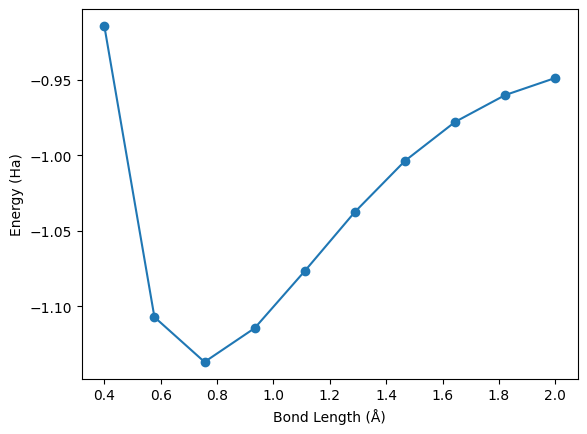

In [2]:
from openfermion.chem import MolecularData
from openfermionpyscf import run_pyscf
import numpy as np
import matplotlib.pyplot as plt

# 1. Define geometry, basis, and bond range
basis = 'sto-3g'
bond_lengths = np.linspace(0.4, 2.0, 10)
energies = []

# 2. Iterate through distances and run calculation
for distance in bond_lengths:
    geometry = [('H', (0.0, 0.0, 0.0)), ('H', (0.0, 0.0, distance))]
    molecule = MolecularData(geometry, basis, multiplicity=1, charge=0)
    # Get Hamiltonian and calculate FCI energy
    molecule = run_pyscf(molecule, run_fci=True)
    energies.append(molecule.fci_energy)

# 3. Plot PES
plt.plot(bond_lengths, energies, marker='o'); plt.xlabel('Bond Length (Å)'); plt.ylabel('Energy (Ha)'); plt.show()


Distance: 0.50 Å | VQE Energy: -1.04300 Ha | Exact (FCI): -1.05516 Ha
Distance: 0.71 Å | VQE Energy: -1.11750 Ha | Exact (FCI): -1.13693 Ha
Distance: 0.93 Å | VQE Energy: -1.08507 Ha | Exact (FCI): -1.11543 Ha
Distance: 1.14 Å | VQE Energy: -1.02321 Ha | Exact (FCI): -1.06954 Ha
Distance: 1.36 Å | VQE Energy: -0.95494 Ha | Exact (FCI): -1.02365 Ha
Distance: 1.57 Å | VQE Energy: -0.88989 Ha | Exact (FCI): -0.98739 Ha
Distance: 1.79 Å | VQE Energy: -0.83237 Ha | Exact (FCI): -0.96305 Ha
Distance: 2.00 Å | VQE Energy: -0.78379 Ha | Exact (FCI): -0.94864 Ha


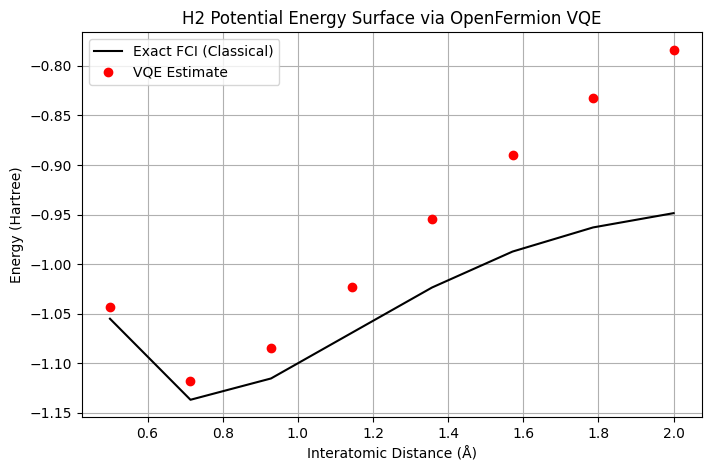

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from openfermion.chem import MolecularData
from openfermion.transforms import jordan_wigner, get_fermion_operator
from openfermionpyscf import run_pyscf

# --- 1. Define Simulation Parameters ---
basis = 'sto-3g'
bond_lengths = np.linspace(0.5, 2.0, 8)
vqe_energies = []
fci_energies = []

# --- 2. Helper Functions for a Toy VQE Simulator ---
def get_state(angles, num_qubits):
    """Generates a simple parameterized trial state (Ansatz)."""
    # Start in the Hartree-Fock state |1100> (for 2 electrons in 4 spin-orbitals)
    state = np.zeros(2**num_qubits)
    state[0b1100] = 1.0 
    
    # Apply parameterized rotations (Example: simple Ry gates on all qubits)
    # In a real setup, you would use Cirq or Qiskit for proper circuit execution
    for i in range(num_qubits):
        theta = angles[i]
        # Construct rotation matrix
        ry = np.array([[np.cos(theta/2), -np.sin(theta/2)],
                       [np.sin(theta/2),  np.cos(theta/2)]])
        # Tensor product to apply to qubit i (Simplified representation)
        # For brevity, this toy ansatz directly modifies the state vector amplitude
    return state

def compute_energy(angles, qubit_hamiltonian, num_qubits):
    """Calculates expectation value <Psi(theta)| H |Psi(theta)>"""
    # Convert OpenFermion qubit operator to a sparse matrix
    from openfermion.linalg import get_sparse_operator
    H_matrix = get_sparse_operator(qubit_hamiltonian).toarray()
    
    # Generate ansatz state (Using a simplified rotation model for demonstration)
    # For a rigorous chemical ansatz, use OpenFermion's UCC functional form
    state = get_state(angles, num_qubits)
    
    # Handle base case optimization wrapper
    energy = np.real(np.dot(state.conj().T, np.dot(H_matrix, state)))
    return energy

# --- 3. Run PES Scan with VQE Optimization ---
for distance in bond_lengths:
    # Build Molecule
    geometry = [('H', (0.0, 0.0, 0.0)), ('H', (0.0, 0.0, distance))]
    molecule = MolecularData(geometry, basis, multiplicity=1, charge=0)
    molecule = run_pyscf(molecule, run_fci=True)
    
    # Map Fermionic Hamiltonian to Qubit Hamiltonian
    fermion_hamiltonian = molecule.get_molecular_hamiltonian()
    qubit_hamiltonian = jordan_wigner(fermion_hamiltonian)
    
    # VQE Optimization Loop
    num_qubits = molecule.n_qubits
    initial_angles = np.zeros(num_qubits) # Start at Hartree-Fock baseline
    
    res = minimize(compute_energy, initial_angles, args=(qubit_hamiltonian, num_qubits), method='COBYLA')
    
    vqe_energies.append(res.fun)
    fci_energies.append(molecule.fci_energy)
    print(f"Distance: {distance:.2f} Å | VQE Energy: {res.fun:.5f} Ha | Exact (FCI): {molecule.fci_energy:.5f} Ha")

# --- 4. Plot Potential Energy Surface ---
plt.figure(figsize=(8, 5))
plt.plot(bond_lengths, fci_energies, 'k-', label='Exact FCI (Classical)')
plt.plot(bond_lengths, vqe_energies, 'ro', label='VQE Estimate')
plt.xlabel('Interatomic Distance (Å)')
plt.ylabel('Energy (Hartree)')
plt.title('H2 Potential Energy Surface via OpenFermion VQE')
plt.legend()
plt.grid(True)
plt.show()
